In [ ]:
# 🎬 Scenario: Movie Streaming Platform
# A movie streaming company has collected data on 1,000 users, including:
# - Average watch time per week
# - Preferred genres (action, comedy, drama, etc.)
# - Number of devices used (TV, phone, tablet)
# - Frequency of subscription pauses or cancellations
# The company wants to group users into meaningful segments to:
# - Recommend personalized movie lists
# - Design loyalty rewards for binge‑watchers
# - Identify users at risk of canceling subscriptions
# Your Tasks
# - Apply K‑Means clustering to explore possible user segments.
# - Example clusters: “Weekend binge‑watchers,” “Casual family viewers,” “Genre loyalists.”
# - Use the Elbow Method to find the point where adding more clusters doesn’t improve grouping much.
# - This helps decide whether 3, 4, or 5 clusters make sense.
# - Validate with Silhouette Score to check if the chosen clusters are well‑separated and meaningful.
# - Ensures that “binge‑watchers” aren’t mixed up with “casual viewers.”

#step 1: import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

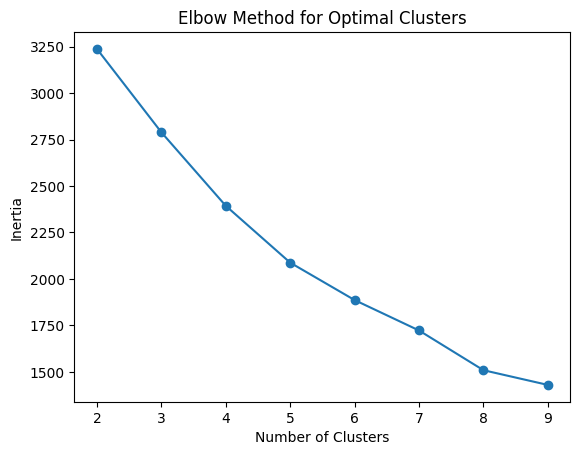

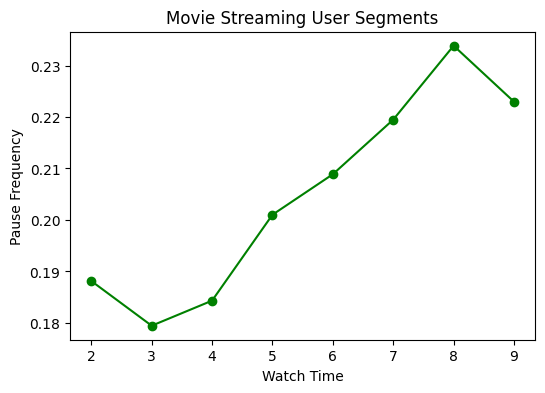

Best K based on silhouette score: 8


In [ ]:
# Step 2: Create synthetic movie streaming dataset
# (In practice, replace with real platform user data)
data = {
    'UserID': range(1, 1001),
    'WatchTime': np.random.randint(2, 30, 1000),
    'DevicesUsed': np.random.randint(1, 4, 1000),
    'PauseFrequency': np.random.randint(0, 6, 1000),
    'GenrePreference': np.random.randint(1, 6, 1000)
}

df = pd.DataFrame(data)

# Step 3: Select Features
X = df[['WatchTime', 'DevicesUsed', 'PauseFrequency', 'GenrePreference']]

# Step 4: Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Elbow Method

inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow method
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

#step 6: Silhouette Score
silhouette_scores = []
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(x_scaled)
  score = silhouette_score(x_scaled, labels)
  silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title('Movie Streaming User Segments')
plt.xlabel('Watch Time')
plt.ylabel('Pause Frequency')
plt.show()

#step 7: Print best K suggestion
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best K based on silhouette score: {best_k}")

